# Chapter 14: Quantum Noise

--

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [ ]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from Chapter08_QuantumGates_functions import simulate_measurements,runCircuitOnIBMQuantum

## Depolarizing noise model

### Example 1: X gate

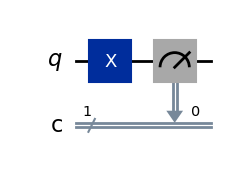

Counts: {'1': 9991, '0': 9}
P(1): 0.9991


In [2]:
p1 = 1 - 0.999   # single-qubit error rate
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p1, 1), ['x'])

qc = QuantumCircuit(1, 1)
qc.x(0)
qc.measure(0, 0)
display(qc.draw('mpl'))
nShots = 10000
counts = simulate_measurements(qc, shots=nShots, noise_model=noise_model)    
print('Counts:', counts)
print('P(1):', counts.get('1', 0) / nShots)

### Example 2: H and CNOT gates

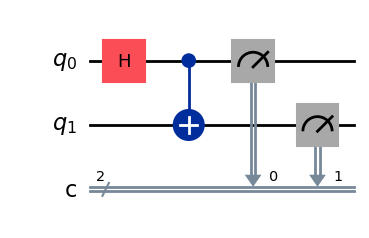

Counts: {'11': 5026, '00': 4933, '01': 21, '10': 20}


In [3]:
p1 = 1 - 0.999   # single-qubit error rate
p2 = 1 - 0.99    # two-qubit error rate

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p1, 1), ['h'])
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p2, 2), ['cx'])

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
display(qc.draw('mpl'))

nShots = 10000
counts = simulate_measurements(qc, shots=nShots, noise_model=noise_model)    
print('Counts:', counts)

### Example: State Preparation; impact of circuit depth

m=2: n1=2, n2=1, F_theory=0.9880, F_measured=0.9928


c:\Users\ksure\anaconda3\envs\quantum\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


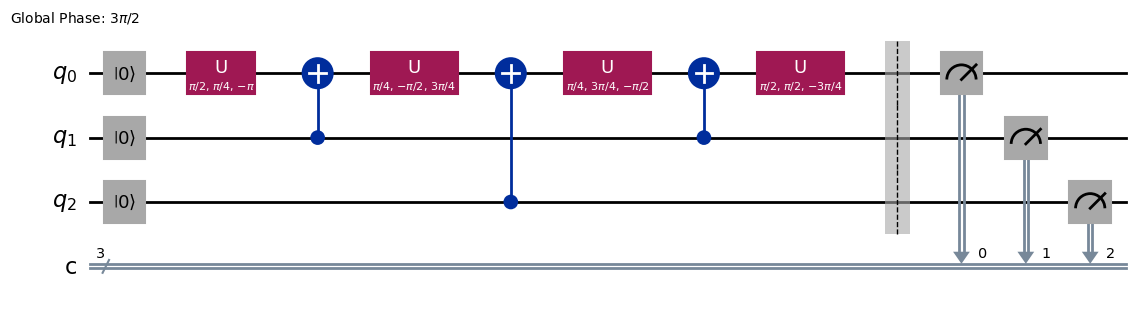

m=3: n1=4, n2=3, F_theory=0.9664, F_measured=0.9729
m=4: n1=8, n2=7, F_theory=0.9246, F_measured=0.9460
m=5: n1=16, n2=15, F_theory=0.8464, F_measured=0.8867
m=6: n1=32, n2=31, F_theory=0.7092, F_measured=0.7848
m=7: n1=64, n2=63, F_theory=0.4980, F_measured=0.6218
m=8: n1=128, n2=127, F_theory=0.2455, F_measured=0.4117


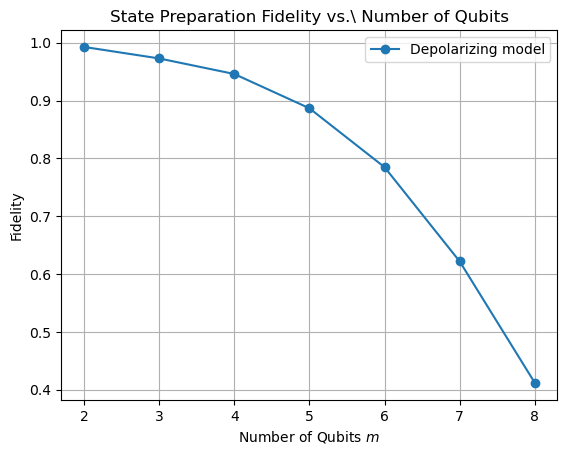

In [4]:
F1 = 0.999
F2 = 0.99
p1 = 1 - F1
p2 = 1 - F2
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p1, 1), ['u', 'rx', 'ry', 'rz', 'h', 'x', 'p'])
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p2, 2), ['cx'])

BASIS = ['cx', 'u', 'x', 'h', 'ry', 'rz', 'rx', 'p']
simulator       = AerSimulator(noise_model=noise_model)
nShots = 10000

m_list         = list(range(2, 9)) 
F_measured_list = []
F_theory_list   = []
F_hardware_list = []
for m in m_list:
    N = 2**m
    b = np.zeros(N)
    b[1] = 1.0
    
    qc = QuantumCircuit(m, m)
    qc.initialize(b, range(m))
    qc.barrier()
    qc.measure(range(m), range(m))
    
    qc_decomposed = qc.decompose(reps=3)
    qc_t = transpile(qc_decomposed, simulator,
                     basis_gates=BASIS)
    
    if (m == 3):
        display(qc_t.draw('mpl'))
    # Gate counts
    ops = qc_t.count_ops()
    n1  = sum(ops.get(g, 0) for g in
              ['u', 'rx', 'ry', 'rz', 'h', 'x', 'p'])
    n2  = ops.get('cx', 0)
    F_theory = (F1**n1) * (F2**n2)
    
    # Measured fidelity
    counts_noisy = simulator.run(qc_t, shots=nShots).result().get_counts()
    correct      = format(1, f'0{m}b')
    F_measured   = counts_noisy.get(correct, 0) / nShots
    
    F_theory_list.append(F_theory)
    F_measured_list.append(F_measured)
    print(f'm={m}: n1={n1}, n2={n2}, '
          f'F_theory={F_theory:.4f}, F_measured={F_measured:.4f}')
    
    # counts_hardware = runCircuitOnIBMQuantum(qc_t, shots=nShots, min_num_qubits=m)
    # F_hardware  = counts_hardware.get(correct, 0) / nShots
    # print(f'm={m}: F_hardware={F_hardware:.4f}')
    # F_hardware_list.append(F_hardware)

plt.figure()
plt.plot(m_list, F_measured_list, 'o-',  label='Depolarizing model')
#plt.plot(m_list, F_theory_list,   'r--', label=r'Bit-flip model')
#plt.plot(m_list, F_hardware_list, 's-', label='Hardware')
plt.xlabel('Number of Qubits $m$')
plt.ylabel('Fidelity')
plt.title('State Preparation Fidelity vs.\ Number of Qubits')
plt.legend()
plt.grid()
plt.show()